In [1]:
from pathlib import Path

import numpy as np
import torch
from matplotlib import pyplot as plt

from e2e.data.dataset import ShapeDataset
from e2e.helpers import timing

timing.ENABLE_TIMING = True
from e2e.data.loader import EXPERIMENT as EXP
from e2e.models.recurrent import LSTM
from e2e.prediction.end_to_end import DataLoader, ModelHandler, Plotter, Predictor

PROJECT_NAME = "waam-e2e-pre"
RUN_ID = "q2btbt08"

# "oqfrcpcw"
# "oqfrcpcw"
# "isn0h9ws"  # first_in_row + 2x
# "xtuq679p"    # first_in_row + 4x
VERSION = "best"
VM_DATA_DIR = Path("/home/magnus/datasets/waam/30_processing_results/ImageGenerator")
INPUT_LENGTH = 90
TARGET_LENGTH = 90
P = 0.5

2023-09-28 09:10:08,655 - MainThread - INFO - torch.distributed.nn.jit.instantiator - Created a temporary directory at /tmp/tmp6_uw7cta
2023-09-28 09:10:08,657 - MainThread - INFO - torch.distributed.nn.jit.instantiator - Writing /tmp/tmp6_uw7cta/_remote_module_non_scriptable.py


In [5]:
lstm = LSTM(
    p=P, n_input_features=INPUT_LENGTH, n_output_features=TARGET_LENGTH, n_hidden=TARGET_LENGTH * 3, n_layers=10
)
model_handler = ModelHandler(PROJECT_NAME, RUN_ID, VERSION, lstm=lstm)

wandb: Downloading large artifact model-q2btbt08:best, 65.29MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.1


In [ ]:
data_loader = DataLoader(VM_DATA_DIR)
cross_section_samples = data_loader.load_samples([EXP.RANDOM_EX6])
dataset = ShapeDataset(mirror=False, segment_length=TARGET_LENGTH).create(cross_section_samples)
predictor = Predictor(TARGET_LENGTH, model_handler, cross_section_samples)

In [3]:
UNCERT_THRESH = 5.0
init_input = torch.tensor(dataset[0][0], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
predictions, labels, ground_truth = predictor.predict(init_input, uncertainty_threshold=UNCERT_THRESH, mode="e2e")

/tmp/ipykernel_519920/507628184.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  init_input = torch.tensor(dataset[0][0], dtype=torch.float32).unsqueeze(0).unsqueeze(0)


function predict_with_uncertainty took 0.566028356552124 s
uncertainty_score@0: 3.0744946002960205
function predict_with_uncertainty took 0.22565770149230957 s
uncertainty_score@1: 2.909242630004883
function predict_with_uncertainty took 0.225325345993042 s
uncertainty_score@2: 2.9564075469970703
function predict_with_uncertainty took 0.22537970542907715 s
uncertainty_score@3: 2.727842330932617
function predict_with_uncertainty took 0.22617530822753906 s
uncertainty_score@4: 2.5497424602508545
function predict_with_uncertainty took 0.2253427505493164 s
uncertainty_score@5: 2.366774320602417
function predict_with_uncertainty took 0.22539448738098145 s
uncertainty_score@6: 3.1556944847106934
function predict_with_uncertainty took 0.22458600997924805 s
uncertainty_score@7: 2.94931960105896
function predict_with_uncertainty took 0.22661995887756348 s
uncertainty_score@8: 4.588962078094482
function predict_with_uncertainty took 0.22530293464660645 s
uncertainty_score@9: 3.8506197929382324
f

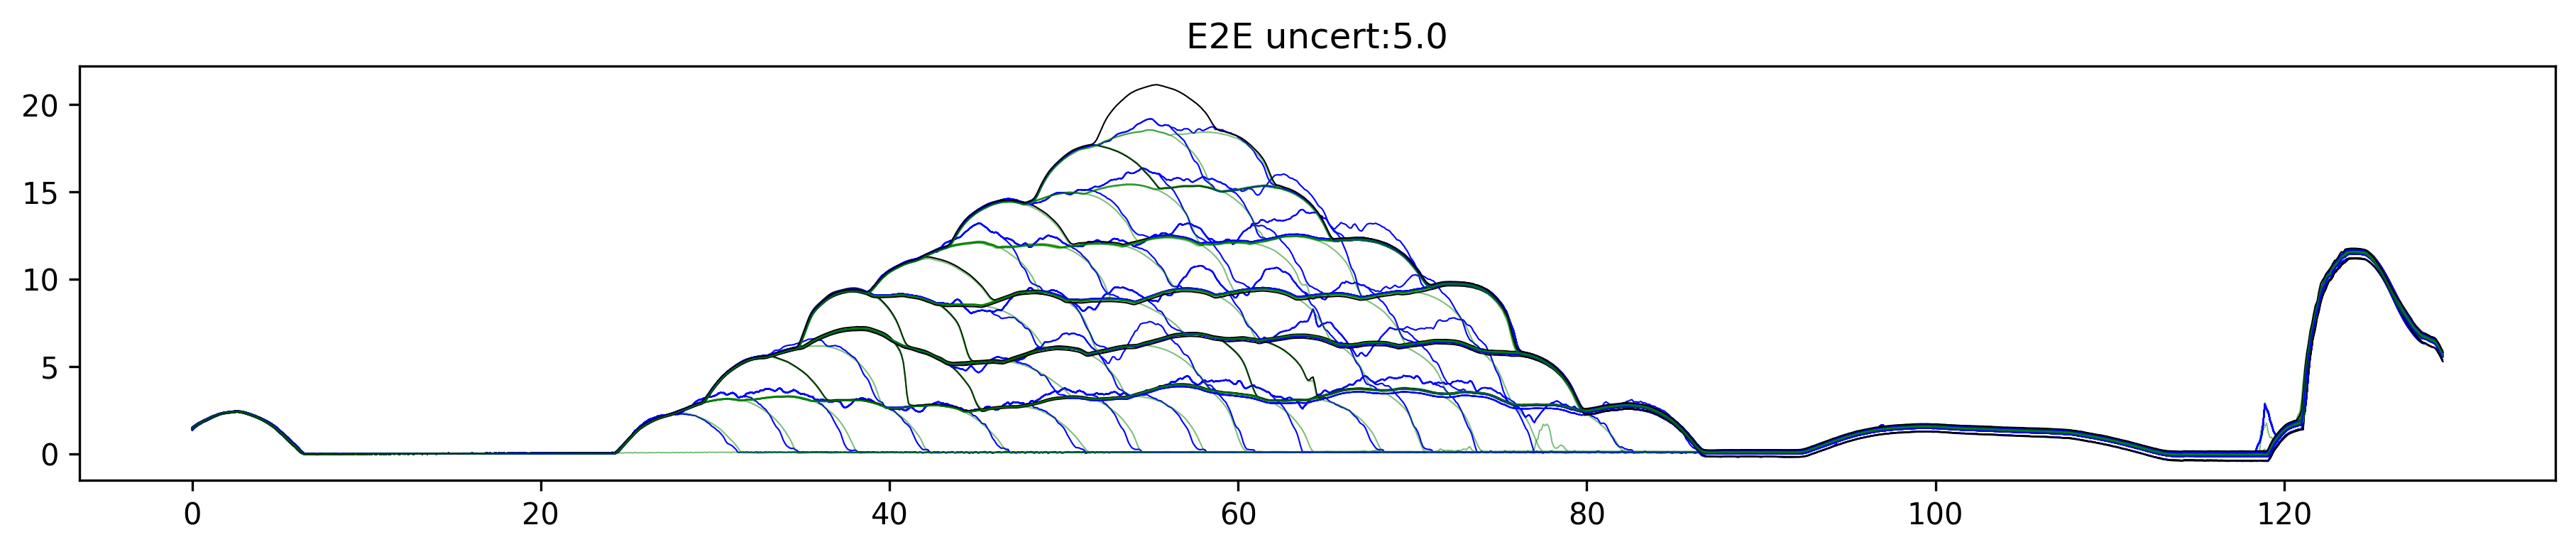

fallback rate to alternative prediction: 23.21%


In [4]:
Plotter.plot_e2e(predictions, labels, ground_truth, title=f"E2E uncert:{UNCERT_THRESH}")
print(f"fallback rate to alternative prediction: {np.sum(labels)/len(labels)*100:.2f}%")

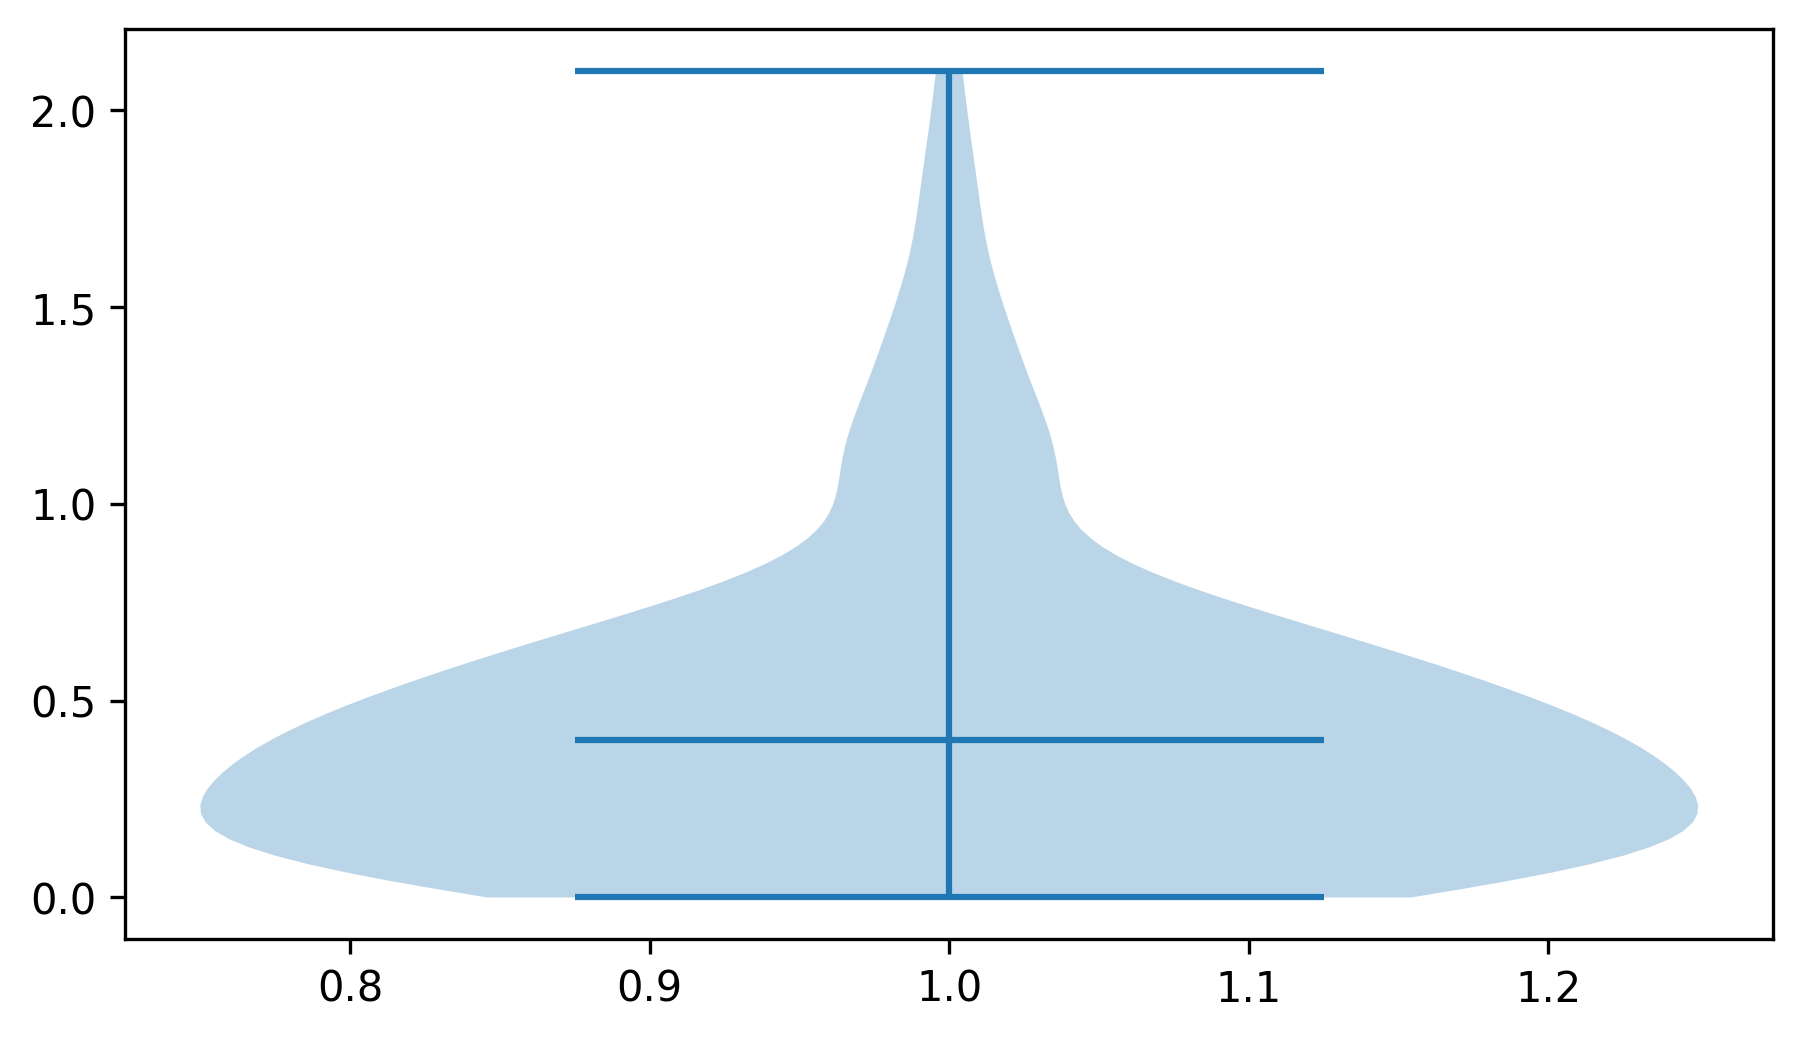

In [8]:
footprint_errors = predictor.footprint_errors
# plot violin plot of footprint errors
cm = 1 / 2.54
fig, ax = plt.subplots(figsize=(18 * cm, 10 * cm), dpi=300)

# labels = ["Footprint Errors"]

v1 = ax.violinplot(dataset=np.array(footprint_errors).reshape(-1) * 0.1, showmedians=True, showmeans=False, showextrema=True, widths=0.5)
plt.show()

In [7]:
np.array(footprint_errors)

array([[ 0,  2],
       [ 1,  2],
       [ 1,  0],
       [ 3,  1],
       [ 3,  0],
       [ 3,  1],
       [ 3,  1],
       [ 1,  1],
       [ 7,  6],
       [ 3,  5],
       [ 2,  1],
       [ 5,  4],
       [ 3,  3],
       [ 1,  5],
       [ 2,  6],
       [ 3,  1],
       [ 7,  5],
       [ 1,  1],
       [21, 11],
       [ 5,  0],
       [ 4,  4],
       [ 3,  1],
       [ 4,  4],
       [15,  4],
       [ 5,  1],
       [ 1,  0],
       [ 4, 11],
       [ 1,  2],
       [ 7,  5],
       [ 7, 12],
       [ 8, 15],
       [11,  6],
       [ 1,  3],
       [13,  8],
       [ 3, 10],
       [ 4,  8],
       [ 6,  4],
       [ 4, 11],
       [ 5, 19],
       [12,  7],
       [ 5, 13],
       [ 9,  2],
       [ 7, 14],
       [ 2, 18],
       [14, 17],
       [ 9, 16],
       [11,  1],
       [ 4,  6],
       [ 3,  3],
       [ 2,  0],
       [ 5,  6],
       [ 1,  2],
       [13,  1],
       [ 9,  4],
       [ 3, 11],
       [ 0,  2],
       [ 1,  1],
       [ 1,  0],
       [ 3,  1

In [12]:
from e2e.data.datamodule import ShapePredictionDataModule

SEED = 2345078

datamodule = ShapePredictionDataModule(
    batch_size=16,
    data_dir=VM_DATA_DIR,
    workers=1,
    dataset=ShapeDataset(mirror=False, segment_length=TARGET_LENGTH),
    split=[0.7, 0.3, 0],
    train_val_sets=[EXP.CONSTANT_EX3, EXP.CONSTANT_EX4, EXP.RANDOM_EX3, EXP.RANDOM_EX5],
    separate_test_set=EXP.RANDOM_EX6,
    seed=SEED,
)

In [13]:
datamodule.setup(stage="fit")

100%|██████████| 265/265 [00:20<00:00, 13.02it/s]


158
238


100%|██████████| 265/265 [00:08<00:00, 31.36it/s]


In [24]:
from scipy.spatial.distance import cdist
model = model_handler
val_data_loader = datamodule.test_dataloader()
modhaussdorff = []

for batch in val_data_loader:
    inputs, targets, ids, fp = batch
    
    pred_diff, *_ = model.model(inputs.to(model.model.device))
    preds = inputs + pred_diff.detach().cpu()
    
    x = np.arange(0, len(preds) / 10, 0.1)
    
    for b in range(len(preds)):
        left = fp[b, 0]
        right = fp[b, 1]
        dist = cdist(list(zip(x, targets[b, left:right])), list(zip(x, preds[b, left:right])))
        modhaussdorff.append((np.median(np.min(dist, axis=1))))
        

In [25]:
len(modhaussdorff)

56

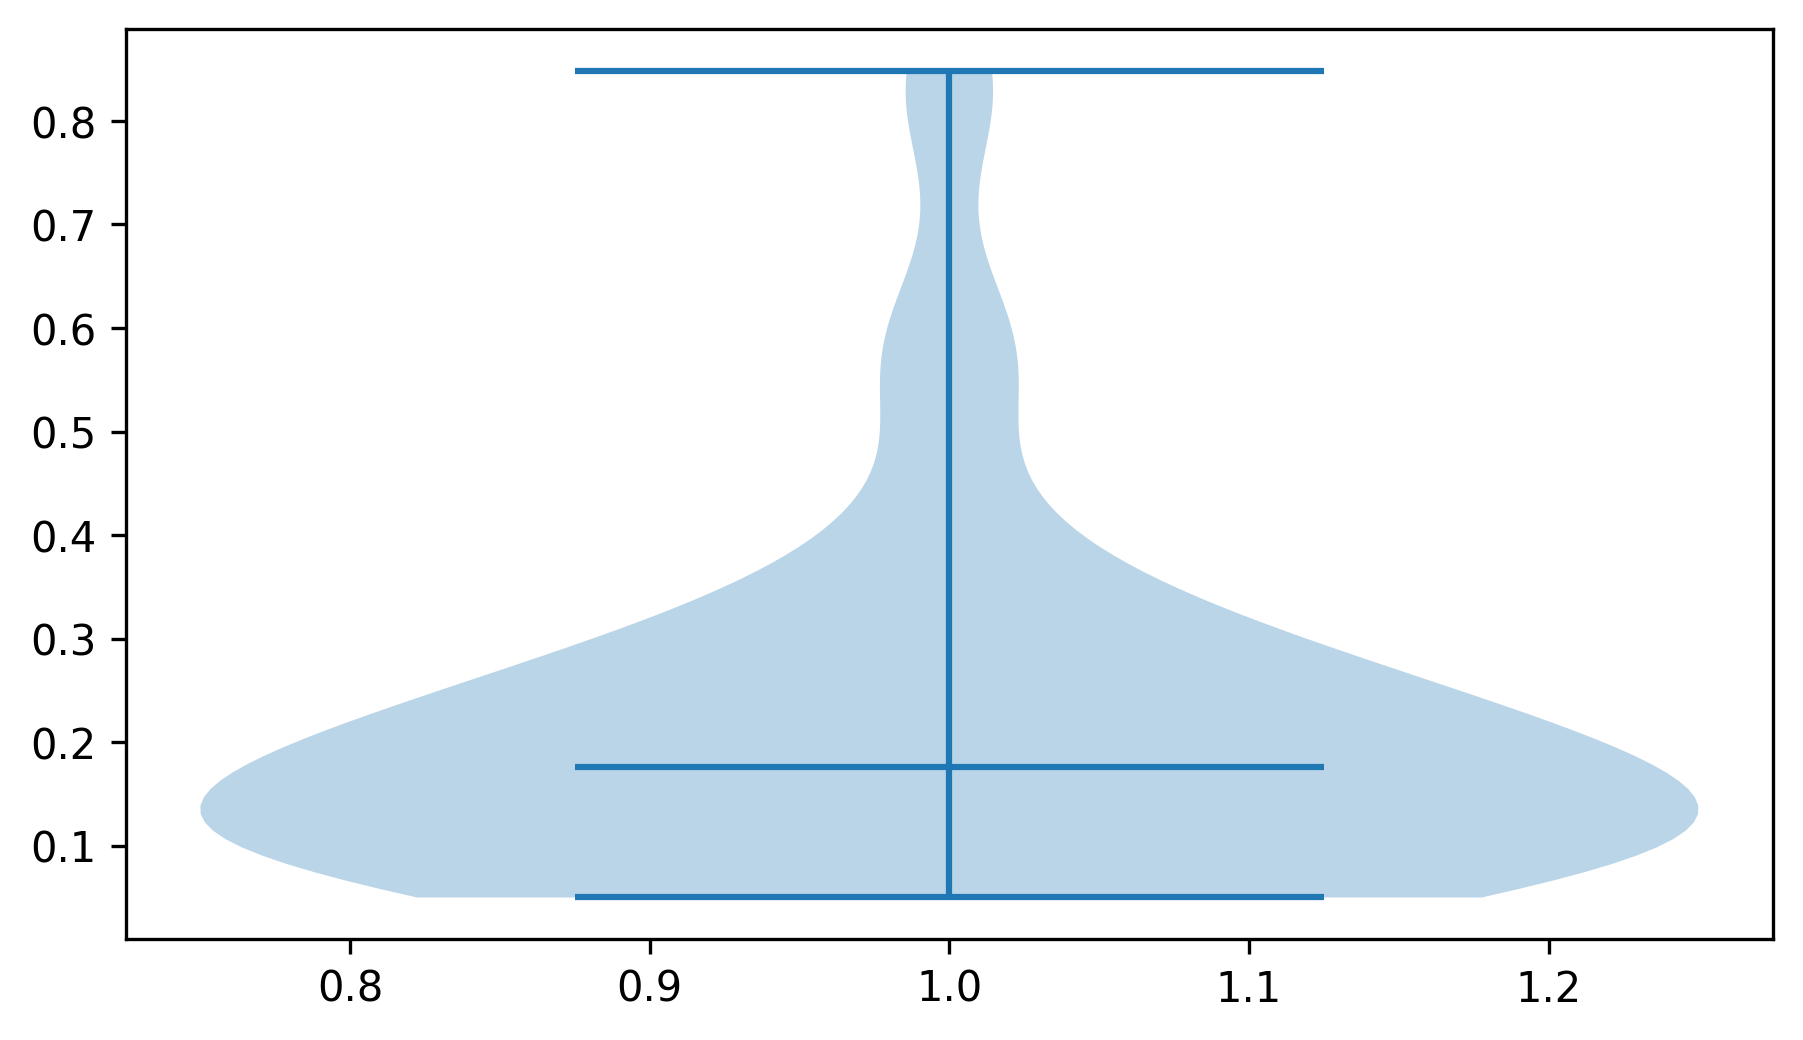

In [26]:
cm = 1 / 2.54
fig, ax = plt.subplots(figsize=(18 * cm, 10 * cm), dpi=300)
v1 = ax.violinplot(dataset=np.array(modhaussdorff), showmedians=True, showmeans=False, showextrema=True, widths=0.5)
plt.show()